<a href="https://colab.research.google.com/github/fabiankmroh/aistudy/blob/master/multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [4]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train = True, download = True, transform = transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train = False, download = True, transform = transform)

In [5]:
print("Train:", train_DS)
print(len(train_DS))
print("Test:", test_DS)
print(len(test_DS))

Train: Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()
60000
Test: Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Test
    StandardTransform
Transform: ToTensor()
10000


In [6]:
train_DS.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [8]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [9]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

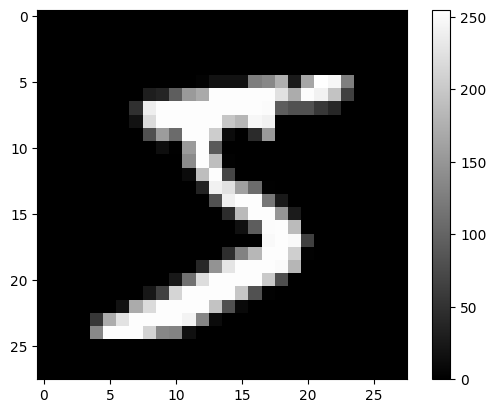

In [10]:
plt.imshow(train_DS.data[0], cmap = "gray")
plt.colorbar()

In [11]:
print(train_DS.targets)

tensor([5, 0, 4,  ..., 5, 6, 8])


In [12]:
BATCH_SIZE = 32
train_DL = torch.utils.data.DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size = BATCH_SIZE, shuffle = True)

In [13]:
train_DL.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [14]:
x_batch, y_batch = next(iter(train_DL))

print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)

print(train_DS.data[0])

<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
torch.uint8
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,

<class 'torch.Tensor'>
torch.Size([32, 1, 28, 28])
torch.float32
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 

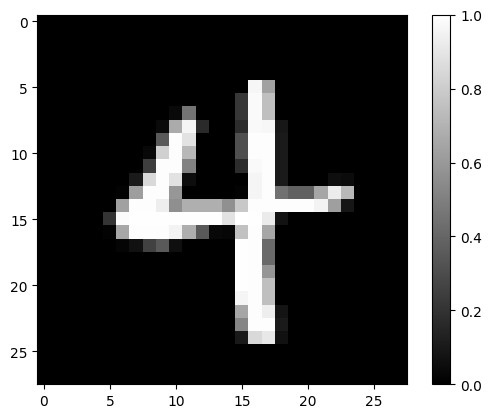

In [15]:
print(type(x_batch))
print(x_batch.shape)
print(x_batch.dtype)
print(x_batch[0])

plt.imshow(x_batch[0].squeeze(), cmap = 'gray')
plt.colorbar()
print(y_batch[0])

In [16]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [17]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [18]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [19]:
# Model

from torch import nn

In [20]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fcs = nn.Sequential(
        nn.Linear(28*28, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    )

  def forward(self, x):
    x = torch.flatten(x, start_dim = 1)
    x = self.fcs(x)

    return x

In [21]:
# Flatten 확인
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

flat_images = torch.flatten(x_batch)
print(flat_images.shape)

flat_images2 = torch.flatten(x_batch, start_dim = 1)
print(flat_images2.shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


In [22]:
model = MLP().to(DEVICE)
print(model)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)


In [23]:
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

torch.Size([32, 10])


In [24]:
# Train
from torch import optim

In [25]:
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = LR)

In [26]:
def Train(model, train_DL, criterion, optimizer, EPOCH):
  loss_history = []
  NoT = len(train_DL.dataset) # No of Training Data

  model.train() # Switch to Train Mode
  for ep in range(EPOCH):
    rloss = 0 # Running Loss

    for x_batch, y_batch in train_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      # Inference
      y_hat = model(x_batch)

      # Loss
      loss = criterion(y_hat, y_batch)

      # Update
      optimizer.zero_grad() # Prevent Gradient Accumulation
      loss.backward() # Backprop
      optimizer.step() # Update Weights (FORGOT THIS)

      loss_b = loss.item() * x_batch.shape[0] # Batch Loss = Loss
      rloss += loss_b

    # Print Loss
    loss_e = rloss / NoT # Epoch Loss = Running Loss / No of Training Data
    loss_history += [loss_e]

    print(f"Epoch {ep+1}: Training Loss {loss_e:.3f}")
    print("-"*20)

  return loss_history

Epoch 1: Training Loss 0.318
--------------------
Epoch 2: Training Loss 0.148
--------------------
Epoch 3: Training Loss 0.101
--------------------
Epoch 4: Training Loss 0.076
--------------------
Epoch 5: Training Loss 0.061
--------------------


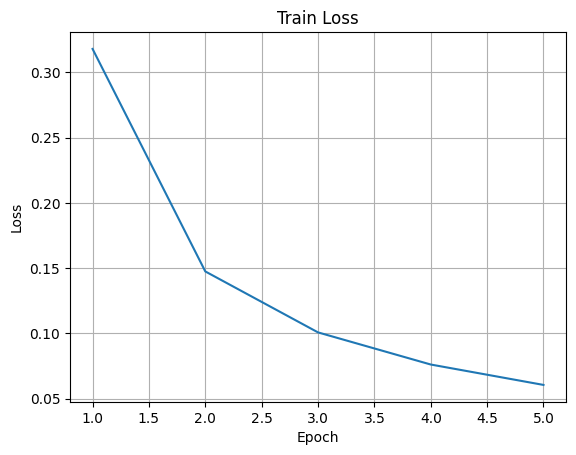

In [27]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

plt.plot(range(1, EPOCH + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")

plt.grid()

In [28]:
# Save Model: All in Comments -> Save X
"""
save_model_path = '/content/drive/MyDrive/Colab Notebooks/model.pth'
torch.save(model.state_dict(), save_model_path)
"""

"\nsave_model_path = '/content/drive/MyDrive/Colab Notebooks/model.pth'\ntorch.save(model.state_dict(), save_model_path)\n"

In [29]:
# Load Model: All in Comments -> No Saved Models
"""
load_model = MLP().to(DEVICE)
load_model.load_state_dict(torch.load(save_model_path, map_location = DEVICE))
"""

'\nload_model = MLP().to(DEVICE)\nload_model.load_state_dict(torch.load(save_model_path, map_location = DEVICE))\n'

In [30]:
# Test Model
def Test(model, test_DL):
  model.eval() # Switch to Test Mode

  with torch.no_grad():
    rcorrect = 0

    for x_batch, y_batch in test_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      y_hat = model(x_batch)

      pred = y_hat.argmax(dim = 1)
      corrects_b = torch.sum(pred == y_batch).item()
      rcorrect += corrects_b

    accuracy = rcorrect / len(test_DL.dataset) * 100

  print(f"Test Accuracy: {rcorrect} / {len(test_DL.dataset)} ({accuracy:.1f} %)")

  return accuracy

In [31]:
Test(model, test_DL)

Test Accuracy: 9729 / 10000 (97.3 %)


97.28999999999999

In [32]:
def Test_plot(model, test_DL):
  model.eval()
  with torch.no_grad():
    x_batch, y_batch = next(iter(test_DL))
    x_batch = x_batch.to(DEVICE)

    y_hat = model(x_batch)
    pred = y_hat.argmax(dim = 1)

  x_batch = x_batch.to("cpu")

  plt.figure(figsize = (8,4))
  for idx in range(6):
    plt.subplot(2,3, idx+1, xticks=[], yticks = [])
    plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap = "gray")

    pred_class = test_DL.dataset.classes[pred[idx]]
    true_class = test_DL.dataset.classes[y_batch[idx]]

    plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class == true_class else "r")

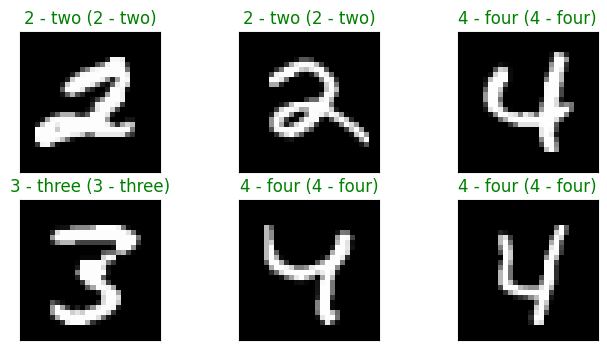

In [34]:
Test_plot(model, test_DL)

In [35]:
# Parameter Numbers
def count_params(model):
  num = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return num

In [36]:
print(count_params(model))

79510


In [37]:
# Confusion Matrix
def get_conf(model, test_DL):
  N = len(test_DL.dataset.classes)
  model.eval()

  with torch.no_grad():
    confusion = torch.zeros(N,N)
    for x_batch, y_batch in test_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      y_hat = model(x_batch) # Inference
      pred = y_hat.argmax(dim = 1) # Accuracy

      confusion += torch.bincount(N * y_batch.cpu() + pred.cpu(), minlength = N**2).reshape(N, N)

  confusion = confusion.numpy()

  return confusion

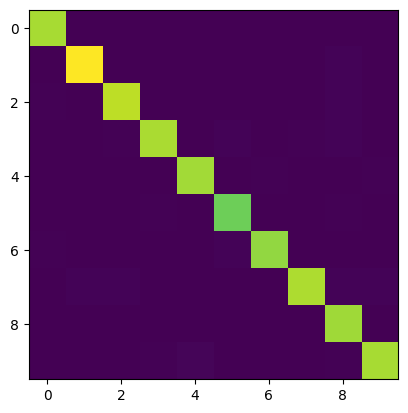

In [38]:
confusion = get_conf(model, test_DL)
plt.imshow(confusion)

In [39]:
import numpy as np

def plot_confusion_matrix(confusion, classes = None):
  N = confusion.shape[0]
  accuracy = np.trace(confusion) / np.sum(confusion) * 100

  plt.figure(figsize = (10,7))
  plt.imshow(confusion, cmap = "Blues")
  plt.title("Confusion Matrix")
  plt.colorbar()

  for i in range(N):
    for j in range(N):
      plt.text(j, i, round(confusion[i, j]),
               horizontalalignment = "center", fontsize = 10,
               color = "white" if confusion[i, j] > np.max(confusion) / 1.5 else "black")

  if classes is not None:
    plt.xticks(range(N), classes)
    plt.yticks(range(N), classes)
  else:
    plt.xticks(range(N))
    plt.yticks(range(N))

  plt.xlabel(f"Predicted Label \n Accuracy = {accuracy:.1f} %")
  plt.ylabel("True Label")

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '0 - zero'),
  Text(1, 0, '1 - one'),
  Text(2, 0, '2 - two'),
  Text(3, 0, '3 - three'),
  Text(4, 0, '4 - four'),
  Text(5, 0, '5 - five'),
  Text(6, 0, '6 - six'),
  Text(7, 0, '7 - seven'),
  Text(8, 0, '8 - eight'),
  Text(9, 0, '9 - nine')])

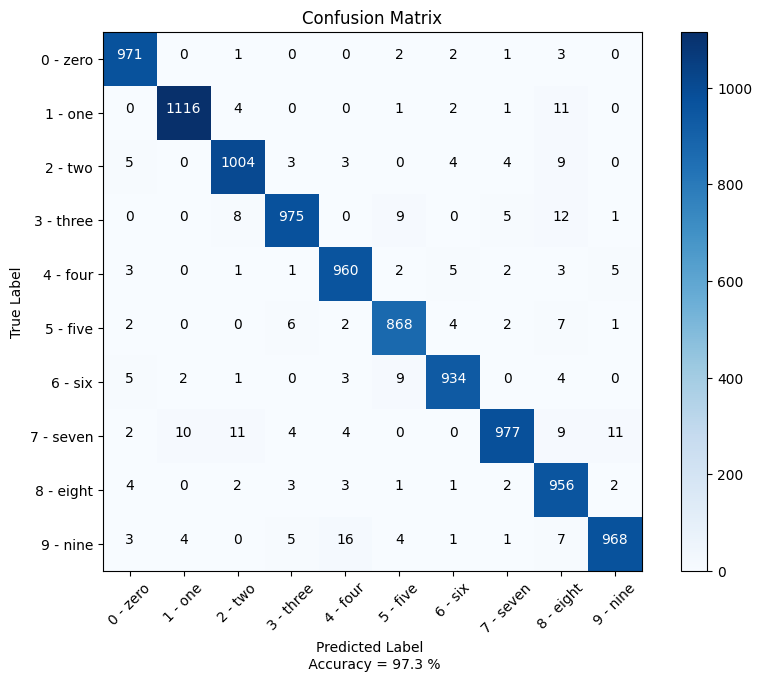

In [41]:
confusion = get_conf(model, test_DL)
plot_confusion_matrix(confusion, test_DL.dataset.classes)
plt.xticks(rotation = 45)